# Машинное обучение для полного новичка: регрессия, классификация и кластеризация

В этом notebook машинное обучение объясняется с нуля. Мы используем один небольшой синтетический набор из **800 клиентов**.

На одном и том же примере будут решены три задачи:

1. **Регрессия** — прогноз числового значения: сколько рублей клиент потратит за месяц.
2. **Классификация** — прогноз класса: станет ли клиент покупателем премиального предложения.
3. **Кластеризация** — поиск похожих групп клиентов без готового правильного ответа.

Все данные созданы искусственно. Они не описывают реальных людей и не предназначены для принятия настоящих решений о клиентах.

## 1. Что такое машинное обучение

**Машинное обучение, или Machine Learning, сокращённо ML**, — это способ научить программу находить закономерности в примерах.

Обычная программа получает правило от разработчика. Например: «если сумма покупки больше 10 000 рублей, начислить скидку».

ML-модель получает много строк с примерами и пытается сама подобрать математическую зависимость. Например, она может заметить, что расходы клиента связаны с доходом, количеством посещений и прошлыми покупками.

Модель не думает и не понимает человека. Она выполняет вычисления на основе данных, которые получила при обучении. Если данные ошибочны или не похожи на будущие случаи, прогноз тоже может быть ошибочным.

## 2. Обучение с учителем и без учителя

В машинном обучении часто выделяют два базовых режима.

### Обучение с учителем — Supervised Learning

В данных есть правильный ответ, который модель должна научиться предсказывать. Такой ответ называют **целевой переменной**, или **target**.

Примеры:

- известны расходы клиентов — можно учить регрессию;
- известно, купил клиент премиальный продукт или нет — можно учить классификацию.

### Обучение без учителя — Unsupervised Learning

Готового правильного ответа нет. Алгоритм ищет внутреннюю структуру данных. Например, объединяет похожих клиентов в группы.

Иногда встречается ошибочная формулировка «Unsupervised Learning — обучение с учителем». Правильно: **это обучение без учителя**.

## 3. Признаки, объект и целевая переменная

Одна строка таблицы описывает один объект. В нашем случае объект — клиент.

**Признаки**, или features, — столбцы, по которым модель делает прогноз. Обычно их обозначают буквой `X`.

Примеры признаков:

- возраст;
- ежемесячный доход;
- число посещений;
- число покупок;
- дни с последней покупки.

**Целевая переменная** — правильный ответ, который нужно предсказать. Её часто обозначают буквой `y`.

В нашем полном датасете две целевые колонки:

- `monthly_spend_rub` — цель регрессии;
- `premium_buyer` — цель классификации.

## 4. Что такое регрессия, классификация и кластеризация

**Регрессия** предсказывает число. Например, сумму расходов, цену квартиры или время доставки.

**Классификация** предсказывает категорию. Например, «купит / не купит», «спам / не спам», «дефект / норма».

**Кластеризация** делит объекты на группы по сходству. У групп заранее нет правильных названий. После расчёта аналитик изучает средние характеристики и даёт группам понятное описание.

В этом notebook используются самые простые модели:

- линейная регрессия;
- логистическая регрессия;
- K-Means.

## 5. Зачем нужны Train и Test

Данные делят на две части.

- **Train**, или обучающая выборка, нужна модели для обучения.
- **Test**, или тестовая выборка, нужна для честной проверки на примерах, которых модель не видела.

Полезная аналогия: Train — это тренировочные задания, Test — контрольная работа.

Если проверить модель на тех же строках, на которых она училась, оценка будет слишком оптимистичной. Поэтому в примерах используется разделение 80% на обучение и 20% на проверку.

Для классификации применяется `stratify=y`. Это помогает сохранить примерно одинаковую долю классов в Train и Test.

## 6. Что такое утечка данных

**Утечка данных, или data leakage**, возникает, когда модель во время обучения получает информацию, которой не будет в момент реального прогноза.

Например, нельзя предсказывать покупку по столбцу, который был рассчитан уже после покупки.

В нашем примере:

- идентификатор клиента не используется как признак;
- при классификации не используется `monthly_spend_rub`, потому что месячные расходы тесно связаны с фактом покупки;
- при кластеризации удаляются обе целевые колонки.

Проверка на утечки важнее выбора сложного алгоритма.

## 7. Что такое масштабирование

Признаки могут измеряться в разных единицах. Доход выражается десятками тысяч рублей, а число обращений — небольшими целыми числами.

`StandardScaler` приводит признаки к сопоставимому масштабу: среднее значение становится близким к нулю, а стандартное отклонение — к единице.

Масштабирование особенно важно для логистической регрессии и K-Means.

Для supervised-задач scaler обучается только на Train. Затем то же преобразование применяется к Test. Иначе информация из тестовой части косвенно попадёт в обучение.

## 8. Baseline — простая точка отсчёта

Перед основной моделью создаётся **baseline**, то есть очень простое решение.

Для регрессии baseline всегда предсказывает среднее значение расходов из Train.

Для классификации baseline всегда выбирает самый частый класс.

Основная модель имеет смысл только тогда, когда она показывает результат лучше baseline. Без такой точки отсчёта высокая на вид метрика может оказаться бесполезной.

## 9. Метрики регрессии

Для регрессии используются три метрики.

- **MAE** — средняя абсолютная ошибка. Если MAE равна 700 рублей, прогноз в среднем отличается от факта примерно на 700 рублей.
- **RMSE** — корень из средней квадратичной ошибки. Эта метрика сильнее штрафует крупные ошибки.
- **R²** — доля разброса целевого значения, объяснённая моделью. Значение ближе к 1 обычно лучше. Значение около 0 означает уровень простого прогноза средним.

Нельзя оценивать модель только по одной метрике. MAE легче объяснить в денежных единицах, а RMSE помогает заметить крупные промахи.

## 10. Метрики классификации

Для классификации используются несколько метрик.

- **Accuracy** — доля всех правильных ответов.
- **Precision** — какая доля прогнозов «премиальный покупатель» оказалась правильной.
- **Recall** — какую долю настоящих премиальных покупателей модель нашла.
- **F1** — общий баланс precision и recall.

Accuracy может вводить в заблуждение, если один класс встречается намного чаще другого. Поэтому дополнительно рассматриваются precision, recall, F1 и матрица ошибок.

## 11. Матрица ошибок

Матрица ошибок показывает четыре типа результата бинарной классификации.

- **True Negative** — модель правильно предсказала класс 0.
- **False Positive** — модель ошибочно предсказала класс 1.
- **False Negative** — модель пропустила настоящий класс 1.
- **True Positive** — модель правильно нашла класс 1.

Стоимость ошибок зависит от задачи. Например, пропуск клиента может означать потерянное предложение, а ложное срабатывание — лишние расходы на коммуникацию.

## 12. Метрики кластеризации

В кластеризации нет готовых правильных ответов. Поэтому качество оценивается иначе.

**Inertia** показывает, насколько объекты близки к центрам своих кластеров. При увеличении числа кластеров inertia почти всегда уменьшается, поэтому ищут точку, после которой улучшение становится небольшим. Это называют методом локтя.

**Silhouette score** сравнивает близость объекта к своему кластеру и к соседним кластерам. Значение ближе к 1 означает более чёткое разделение. Значение около 0 говорит о пересечении групп.

Даже хорошая внутренняя метрика не доказывает, что кластеры полезны для бизнеса. Их нужно интерпретировать.

## 13. Подключение библиотек и настройка файлов

Сейчас подключаются библиотеки и задаются пути. Каждая исполняемая строка имеет комментарий на русском языке.

In [1]:
# Импортируем Path для удобной работы с путями к файлам.
from pathlib import Path
# Импортируем NumPy для числовых расчётов.
import numpy as np
# Импортируем pandas для работы с таблицами.
import pandas as pd
# Импортируем matplotlib для построения графиков.
import matplotlib.pyplot as plt
# Импортируем seaborn для более удобных статистических графиков.
import seaborn as sns
# Импортируем функцию разделения данных на Train и Test.
from sklearn.model_selection import train_test_split
# Импортируем StandardScaler для масштабирования признаков.
from sklearn.preprocessing import StandardScaler
# Импортируем простую линейную регрессию.
from sklearn.linear_model import LinearRegression
# Импортируем логистическую регрессию для классификации.
from sklearn.linear_model import LogisticRegression
# Импортируем простой baseline для регрессии.
from sklearn.dummy import DummyRegressor
# Импортируем простой baseline для классификации.
from sklearn.dummy import DummyClassifier
# Импортируем алгоритм K-Means для кластеризации.
from sklearn.cluster import KMeans
# Импортируем метрики регрессии. RMSE ниже рассчитаем через квадратный корень из MSE для совместимости с разными версиями scikit-learn.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Импортируем метрики классификации.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Импортируем silhouette score для оценки кластеризации.
from sklearn.metrics import silhouette_score
# Импортируем display и Markdown для красивого вывода результатов.
from IPython.display import display, Markdown

# Фиксируем случайное зерно для повторяемых результатов.
RANDOM_STATE = 42
# Создаём генератор случайных чисел с фиксированным зерном.
rng = np.random.default_rng(RANDOM_STATE)
# Устанавливаем спокойный стиль графиков.
sns.set_theme(style='whitegrid', context='notebook')
# Устанавливаем шрифт с поддержкой русского языка.
plt.rcParams['font.family'] = 'DejaVu Sans'
# Устанавливаем стандартный размер графиков.
plt.rcParams['figure.figsize'] = (10, 6)
# Разрешаем pandas показывать все столбцы небольшого датасета.
pd.set_option('display.max_columns', 20)
# Настраиваем отображение чисел с двумя знаками после запятой.
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

# Определяем рабочую папку как папку запуска notebook.
DATA_DIR = Path('.')
# Формируем путь к supervised-датасету.
SUPERVISED_DATA_PATH = DATA_DIR / 'ml_customers_supervised_800.csv'
# Формируем путь к датасету для кластеризации.
CLUSTERING_DATA_PATH = DATA_DIR / 'ml_customers_clustering_800.csv'
# Формируем путь для графика регрессии.
REGRESSION_PLOT_PATH = DATA_DIR / 'regression_predictions.png'
# Формируем путь для матрицы ошибок классификации.
CLASSIFICATION_PLOT_PATH = DATA_DIR / 'classification_confusion_matrix.png'
# Формируем путь для графиков кластеризации.
CLUSTERING_PLOT_PATH = DATA_DIR / 'clustering_results.png'

## 14. Загрузка двух версий данных

Полная версия используется для обучения с учителем. В ней есть признаки и две целевые колонки.

Версия для кластеризации содержит тех же клиентов, но из неё удалены готовые ответы `monthly_spend_rub` и `premium_buyer`.

In [2]:
# Проверяем наличие supervised-датасета.
assert SUPERVISED_DATA_PATH.exists(), f'Не найден файл: {SUPERVISED_DATA_PATH.resolve()}'
# Проверяем наличие clustering-датасета.
assert CLUSTERING_DATA_PATH.exists(), f'Не найден файл: {CLUSTERING_DATA_PATH.resolve()}'
# Загружаем supervised-датасет в таблицу supervised_df.
supervised_df = pd.read_csv(SUPERVISED_DATA_PATH, encoding='utf-8-sig')
# Загружаем clustering-датасет в таблицу clustering_df.
clustering_df = pd.read_csv(CLUSTERING_DATA_PATH, encoding='utf-8-sig')
# Печатаем размер полной таблицы.
print(f'Supervised-датасет: {supervised_df.shape[0]} строк и {supervised_df.shape[1]} столбцов.')
# Печатаем размер таблицы для кластеризации.
print(f'Clustering-датасет: {clustering_df.shape[0]} строк и {clustering_df.shape[1]} столбцов.')
# Показываем первые пять строк полной таблицы.
display(supervised_df.head())
# Показываем первые пять строк таблицы для кластеризации.
display(clustering_df.head())

Supervised-датасет: 800 строк и 10 столбцов.
Clustering-датасет: 800 строк и 8 столбцов.


,customer_id,age,monthly_income_rub,visits_per_month,avg_session_minutes,support_requests_3m,purchases_last_3m,days_since_last_purchase,monthly_spend_rub,premium_buyer
0,CUST0001,51,111747,9,15.00,1,4,16,"6,786.89",0
1,CUST0002,27,89180,9,16.00,2,4,26,"5,920.82",0
2,CUST0003,40,161072,17,17.20,1,10,2,"12,111.01",1
3,CUST0004,46,106413,9,10.10,0,4,27,"7,160.67",0
4,CUST0005,26,30802,2,5.80,1,1,76,754.07,0


,customer_id,age,monthly_income_rub,visits_per_month,avg_session_minutes,support_requests_3m,purchases_last_3m,days_since_last_purchase
0,CUST0001,51,111747,9,15.00,1,4,16
1,CUST0002,27,89180,9,16.00,2,4,26
2,CUST0003,40,161072,17,17.20,1,10,2
3,CUST0004,46,106413,9,10.10,0,4,27
4,CUST0005,26,30802,2,5.80,1,1,76


## 15. Простая проверка качества данных

До моделирования проверяются размер, пропуски, дубликаты и допустимые диапазоны.

Датасет специально создан чистым, чтобы новичок мог сосредоточиться на логике ML. В рабочем проекте проверка качества обычно занимает значительно больше времени.

In [3]:
# Проверяем ожидаемый размер supervised-датасета.
assert supervised_df.shape == (800, 10), 'Ожидалось 800 строк и 10 столбцов.'
# Проверяем ожидаемый размер clustering-датасета.
assert clustering_df.shape == (800, 8), 'Ожидалось 800 строк и 8 столбцов.'
# Проверяем отсутствие пропусков в полной таблице.
assert supervised_df.isna().sum().sum() == 0, 'В supervised-датасете есть пропуски.'
# Проверяем отсутствие пропусков в таблице для кластеризации.
assert clustering_df.isna().sum().sum() == 0, 'В clustering-датасете есть пропуски.'
# Проверяем уникальность идентификаторов в полной таблице.
assert supervised_df['customer_id'].is_unique, 'В supervised-датасете повторяются customer_id.'
# Проверяем уникальность идентификаторов в таблице для кластеризации.
assert clustering_df['customer_id'].is_unique, 'В clustering-датасете повторяются customer_id.'
# Проверяем допустимые значения классификационной цели.
assert supervised_df['premium_buyer'].isin([0, 1]).all(), 'premium_buyer должен содержать только 0 и 1.'
# Показываем типы и заполненность столбцов.
supervised_df.info()
# Показываем описательную статистику числовых полей.
display(supervised_df.describe(include='number').T)
# Печатаем долю положительного класса.
print(f'Доля премиальных покупателей: {supervised_df["premium_buyer"].mean():.1%}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               800 non-null    object 
 1   age                       800 non-null    int64  
 2   monthly_income_rub        800 non-null    int64  
 3   visits_per_month          800 non-null    int64  
 4   avg_session_minutes       800 non-null    float64
 5   support_requests_3m       800 non-null    int64  
 6   purchases_last_3m         800 non-null    int64  
 7   days_since_last_purchase  800 non-null    int64  
 8   monthly_spend_rub         800 non-null    float64
 9   premium_buyer             800 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 62.6+ KB


,count,mean,std,min,25%,50%,75%,max
age,800.00,35.73,10.36,18.00,28.00,35.00,43.00,67.00
monthly_income_rub,800.00,"87,584.72","48,704.37","25,000.00","46,179.75","80,981.00","107,266.00","245,649.00"
visits_per_month,800.00,8.53,6.05,0.00,3.00,8.00,11.00,25.00
avg_session_minutes,800.00,11.39,6.05,1.00,6.17,10.80,14.60,28.90
support_requests_3m,800.00,1.10,0.73,0.00,1.00,1.00,1.00,4.00
purchases_last_3m,800.00,3.90,3.11,0.00,1.00,3.00,6.00,13.00
days_since_last_purchase,800.00,38.07,27.82,0.00,16.00,27.00,65.00,115.00
monthly_spend_rub,800.00,"5,491.10","3,983.54",500.00,"1,911.00","5,169.24","7,068.01","15,808.25"
premium_buyer,800.00,0.26,0.44,0.00,0.00,0.00,1.00,1.00


Доля премиальных покупателей: 25.5%


## 16. Выбор признаков без утечки

Одинаковый список признаков используется для регрессии и классификации.

`customer_id` удаляется, потому что это технический идентификатор, а не характеристика поведения.

При классификации не используется `monthly_spend_rub`. Иначе модель получила бы почти готовый ответ через расходы клиента. Это было бы утечкой.

In [4]:
# Создаём список признаков, доступных до получения целевого ответа.
feature_columns = ['age', 'monthly_income_rub', 'visits_per_month', 'avg_session_minutes', 'support_requests_3m', 'purchases_last_3m', 'days_since_last_purchase']
# Создаём таблицу признаков X для supervised-задач.
X = supervised_df[feature_columns].copy()
# Создаём числовую цель y для регрессии.
y_regression = supervised_df['monthly_spend_rub'].copy()
# Создаём бинарную цель y для классификации.
y_classification = supervised_df['premium_buyer'].copy()
# Проверяем, что идентификатор не попал в признаки.
assert 'customer_id' not in X.columns, 'Идентификатор нельзя использовать как обычный признак.'
# Проверяем, что регрессионная цель не попала в признаки.
assert 'monthly_spend_rub' not in X.columns, 'Обнаружена утечка регрессионной цели.'
# Проверяем, что классификационная цель не попала в признаки.
assert 'premium_buyer' not in X.columns, 'Обнаружена утечка классификационной цели.'
# Показываем первые строки признаков.
display(X.head())

,age,monthly_income_rub,visits_per_month,avg_session_minutes,support_requests_3m,purchases_last_3m,days_since_last_purchase
0,51,111747,9,15.00,1,4,16
1,27,89180,9,16.00,2,4,26
2,40,161072,17,17.20,1,10,2
3,46,106413,9,10.10,0,4,27
4,26,30802,2,5.80,1,1,76


# Регрессия: прогноз месячных расходов

## 17. Разделение данных и baseline регрессии

Цель — предсказать `monthly_spend_rub`.

Сначала данные делятся на Train и Test. Затем создаётся baseline, который всегда предсказывает среднее значение расходов из обучающей части.

In [5]:
# Делим признаки и числовую цель на обучающую и тестовую части.
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X, y_regression, test_size=0.20, random_state=RANDOM_STATE)
# Проверяем отсутствие общих индексов между Train и Test.
assert set(X_reg_train.index).isdisjoint(set(X_reg_test.index)), 'Train и Test пересекаются.'
# Создаём baseline, который всегда предсказывает среднее значение Train.
regression_baseline = DummyRegressor(strategy='mean')
# Обучаем baseline на обучающей части.
regression_baseline.fit(X_reg_train, y_reg_train)
# Получаем прогноз baseline для тестовой части.
y_reg_baseline_pred = regression_baseline.predict(X_reg_test)
# Рассчитываем MAE baseline.
regression_baseline_mae = mean_absolute_error(y_reg_test, y_reg_baseline_pred)
# Печатаем размеры выборок.
print(f'Train: {len(X_reg_train)} строк, Test: {len(X_reg_test)} строк.')
# Печатаем MAE baseline.
print(f'MAE простого baseline: {regression_baseline_mae:,.0f} руб.')

Train: 640 строк, Test: 160 строк.
MAE простого baseline: 3,124 руб.


## 18. Обучение линейной регрессии

Сначала scaler изучает масштаб признаков только на Train. Затем он преобразует Train и Test.

Линейная регрессия подбирает коэффициенты так, чтобы прогнозы были как можно ближе к фактическим значениям по критерию суммы квадратов ошибок.

Масштабирование не обязательно для обычной линейной регрессии, но здесь оно используется для единообразного учебного процесса и удобного сравнения коэффициентов.

RMSE рассчитывается в два понятных шага. Сначала функция `mean_squared_error()` находит среднее квадратов ошибок. Затем `np.sqrt()` извлекает квадратный корень. Такой способ работает и в версиях `scikit-learn`, где отдельной функции `root_mean_squared_error()` ещё нет.


In [6]:
# Создаём scaler для регрессионных признаков.
regression_scaler = StandardScaler()
# Обучаем scaler только на регрессионном Train и сразу преобразуем Train.
X_reg_train_scaled = regression_scaler.fit_transform(X_reg_train)
# Преобразуем Test с параметрами, найденными на Train.
X_reg_test_scaled = regression_scaler.transform(X_reg_test)
# Создаём модель линейной регрессии.
regression_model = LinearRegression()
# Обучаем линейную регрессию на масштабированном Train.
regression_model.fit(X_reg_train_scaled, y_reg_train)
# Получаем прогноз расходов для Test.
y_reg_pred = regression_model.predict(X_reg_test_scaled)
# Рассчитываем MAE основной модели.
regression_mae = mean_absolute_error(y_reg_test, y_reg_pred)
# Сначала рассчитываем MSE основной модели — среднее значение квадратов ошибок.
regression_mse = mean_squared_error(y_reg_test, y_reg_pred)
# Извлекаем квадратный корень из MSE и получаем RMSE в рублях.
regression_rmse = np.sqrt(regression_mse)
# Рассчитываем R² основной модели.
regression_r2 = r2_score(y_reg_test, y_reg_pred)
# Собираем сравнение baseline и модели в таблицу.
regression_metrics = pd.DataFrame({'Модель': ['Baseline: среднее', 'Линейная регрессия'], 'MAE, руб.': [regression_baseline_mae, regression_mae], 'RMSE, руб.': [np.sqrt(mean_squared_error(y_reg_test, y_reg_baseline_pred)), regression_rmse], 'R²': [r2_score(y_reg_test, y_reg_baseline_pred), regression_r2]})
# Показываем таблицу метрик регрессии.
display(regression_metrics)

,Модель,"MAE, руб.","RMSE, руб.",R²
0,Baseline: среднее,"3,124.36","3,990.27",-0.00
1,Линейная регрессия,657.81,812.55,0.96


## 19. График «факт против прогноза»

Каждая точка — один клиент из Test.

По горизонтали находится фактическая сумма расходов, по вертикали — прогноз модели. Пунктирная линия показывает идеальное совпадение.

Чем ближе точки к линии, тем точнее прогноз. Отдельные далёкие точки показывают крупные ошибки, которые стоит изучать отдельно.

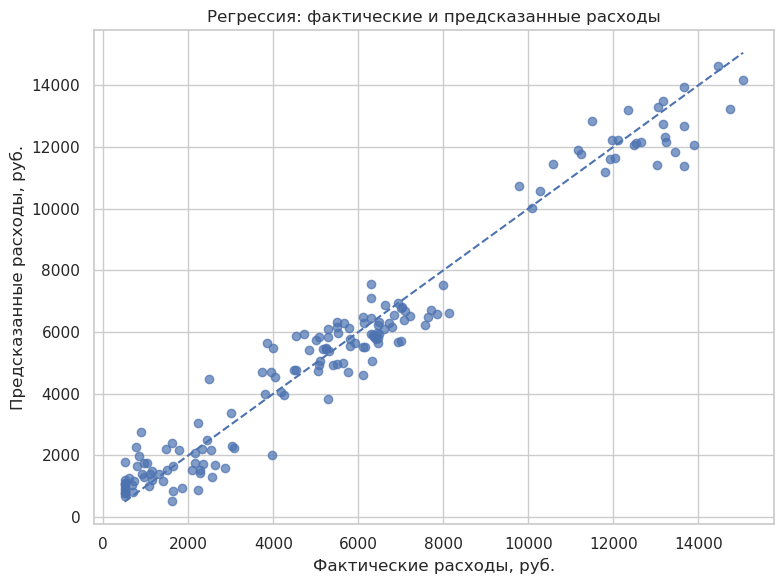

Линейная регрессия уменьшила MAE с 3,124 до 658 руб.


In [7]:
# Создаём фигуру для сравнения факта и прогноза.
fig, ax = plt.subplots(figsize=(8, 6))
# Рисуем точки фактических и предсказанных расходов.
ax.scatter(y_reg_test, y_reg_pred, alpha=0.70)
# Находим минимальное значение для идеальной линии.
regression_min = min(y_reg_test.min(), y_reg_pred.min())
# Находим максимальное значение для идеальной линии.
regression_max = max(y_reg_test.max(), y_reg_pred.max())
# Рисуем пунктирную линию идеального прогноза.
ax.plot([regression_min, regression_max], [regression_min, regression_max], linestyle='--')
# Добавляем понятный заголовок.
ax.set_title('Регрессия: фактические и предсказанные расходы')
# Подписываем горизонтальную ось.
ax.set_xlabel('Фактические расходы, руб.')
# Подписываем вертикальную ось.
ax.set_ylabel('Предсказанные расходы, руб.')
# Корректируем расположение элементов.
plt.tight_layout()
# Сохраняем график в PNG.
fig.savefig(REGRESSION_PLOT_PATH, dpi=170, bbox_inches='tight')
# Показываем график.
plt.show()
# Печатаем краткий вывод по сравнению с baseline.
print(f'Линейная регрессия уменьшила MAE с {regression_baseline_mae:,.0f} до {regression_mae:,.0f} руб.')

## 20. Как читать результат регрессии

Модель сравнивается с baseline на одной и той же тестовой выборке.

Если MAE основной модели заметно меньше MAE baseline, модель действительно извлекла полезную закономерность.

Высокий R² в этом синтетическом примере ожидаем, потому что данные были созданы по относительно простой формуле. На реальных данных качество обычно ниже, а связи сложнее.

# Классификация: прогноз премиального покупателя

## 21. Разделение данных и baseline классификации

Цель `premium_buyer` принимает два значения:

- 0 — клиент не относится к премиальным покупателям;
- 1 — относится.

`stratify=y_classification` сохраняет близкую долю классов в Train и Test. Baseline всегда предсказывает самый частый класс.

In [8]:
# Делим признаки и бинарную цель на Train и Test с сохранением доли классов.
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X, y_classification, test_size=0.20, random_state=RANDOM_STATE, stratify=y_classification)
# Проверяем отсутствие общих индексов между классификационными Train и Test.
assert set(X_cls_train.index).isdisjoint(set(X_cls_test.index)), 'Train и Test пересекаются.'
# Создаём baseline, который всегда выбирает самый частый класс.
classification_baseline = DummyClassifier(strategy='most_frequent')
# Обучаем baseline на классификационном Train.
classification_baseline.fit(X_cls_train, y_cls_train)
# Получаем прогноз baseline для Test.
y_cls_baseline_pred = classification_baseline.predict(X_cls_test)
# Рассчитываем accuracy baseline.
classification_baseline_accuracy = accuracy_score(y_cls_test, y_cls_baseline_pred)
# Печатаем долю класса 1 в Train.
print(f'Доля класса 1 в Train: {y_cls_train.mean():.1%}')
# Печатаем долю класса 1 в Test.
print(f'Доля класса 1 в Test: {y_cls_test.mean():.1%}')
# Печатаем accuracy baseline.
print(f'Accuracy baseline: {classification_baseline_accuracy:.1%}')

Доля класса 1 в Train: 25.5%
Доля класса 1 в Test: 25.6%
Accuracy baseline: 74.4%


## 22. Обучение логистической регрессии

Несмотря на слово «регрессия» в названии, логистическая регрессия используется для классификации.

Она оценивает вероятность класса 1. Затем вероятность превращается в класс по порогу. По умолчанию часто используется порог 0,5.

В этом учебном примере порог не настраивается. В реальном проекте его выбирают с учётом стоимости false positive и false negative.

In [9]:
# Создаём scaler для классификационных признаков.
classification_scaler = StandardScaler()
# Обучаем scaler только на классификационном Train и преобразуем Train.
X_cls_train_scaled = classification_scaler.fit_transform(X_cls_train)
# Преобразуем классификационный Test параметрами Train.
X_cls_test_scaled = classification_scaler.transform(X_cls_test)
# Создаём модель логистической регрессии.
classification_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
# Обучаем модель на масштабированном Train.
classification_model.fit(X_cls_train_scaled, y_cls_train)
# Получаем предсказанные классы для Test.
y_cls_pred = classification_model.predict(X_cls_test_scaled)
# Рассчитываем accuracy основной модели.
classification_accuracy = accuracy_score(y_cls_test, y_cls_pred)
# Рассчитываем precision основной модели.
classification_precision = precision_score(y_cls_test, y_cls_pred, zero_division=0)
# Рассчитываем recall основной модели.
classification_recall = recall_score(y_cls_test, y_cls_pred, zero_division=0)
# Рассчитываем F1 основной модели.
classification_f1 = f1_score(y_cls_test, y_cls_pred, zero_division=0)
# Рассчитываем F1 baseline.
classification_baseline_f1 = f1_score(y_cls_test, y_cls_baseline_pred, zero_division=0)
# Собираем метрики классификации в таблицу.
classification_metrics = pd.DataFrame({'Модель': ['Baseline: частый класс', 'Логистическая регрессия'], 'Accuracy': [classification_baseline_accuracy, classification_accuracy], 'Precision': [precision_score(y_cls_test, y_cls_baseline_pred, zero_division=0), classification_precision], 'Recall': [recall_score(y_cls_test, y_cls_baseline_pred, zero_division=0), classification_recall], 'F1': [classification_baseline_f1, classification_f1]})
# Показываем таблицу метрик классификации.
display(classification_metrics)

,Модель,Accuracy,Precision,Recall,F1
0,Baseline: частый класс,0.74,0.00,0.00,0.00
1,Логистическая регрессия,0.86,0.85,0.54,0.66


## 23. Матрица ошибок классификации

Строки матрицы показывают фактический класс, столбцы — прогноз модели.

Главное внимание стоит уделить двум типам ошибок:

- false positive: клиент ошибочно признан премиальным;
- false negative: настоящий премиальный клиент пропущен.

Какая ошибка важнее, определяет бизнес-задача, а не библиотека.

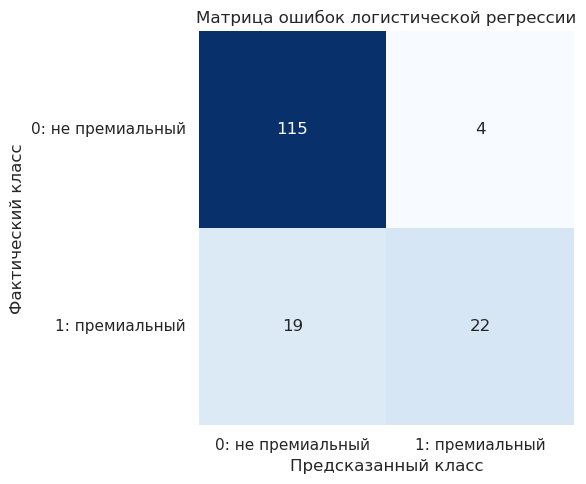

Recall модели: найдено 53.7% настоящих премиальных покупателей в Test.


In [10]:
# Рассчитываем матрицу ошибок.
classification_confusion = confusion_matrix(y_cls_test, y_cls_pred, labels=[0, 1])
# Создаём фигуру для матрицы ошибок.
fig, ax = plt.subplots(figsize=(6, 5))
# Строим тепловую карту матрицы ошибок.
sns.heatmap(classification_confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
# Добавляем заголовок.
ax.set_title('Матрица ошибок логистической регрессии')
# Подписываем горизонтальную ось.
ax.set_xlabel('Предсказанный класс')
# Подписываем вертикальную ось.
ax.set_ylabel('Фактический класс')
# Задаём подписи классов по горизонтали.
ax.set_xticklabels(['0: не премиальный', '1: премиальный'])
# Задаём подписи классов по вертикали.
ax.set_yticklabels(['0: не премиальный', '1: премиальный'], rotation=0)
# Корректируем расположение элементов.
plt.tight_layout()
# Сохраняем матрицу ошибок в PNG.
fig.savefig(CLASSIFICATION_PLOT_PATH, dpi=170, bbox_inches='tight')
# Показываем матрицу ошибок.
plt.show()
# Печатаем краткий вывод о найденной доле положительного класса.
print(f'Recall модели: найдено {classification_recall:.1%} настоящих премиальных покупателей в Test.')

## 24. Как читать результат классификации

Baseline может иметь неплохую accuracy, просто предсказывая самый частый класс. Поэтому смотреть только на accuracy нельзя.

Логистическая регрессия должна превзойти baseline по F1 и начать находить класс 1.

Recall показывает долю найденных премиальных покупателей. Precision показывает, насколько можно доверять положительному прогнозу. Изменение порога меняет баланс этих двух метрик.

# Кластеризация: поиск похожих групп клиентов

## 25. Подготовка данных без целевых колонок

Для кластеризации используется отдельный CSV без готовых ответов.

`customer_id` сохраняется только для связи результата с конкретной строкой, но не участвует в расчёте расстояний.

K-Means чувствителен к масштабу. Поэтому все семь признаков стандартизируются перед кластеризацией.

In [11]:
# Создаём список признаков кластеризации без идентификатора и целей.
clustering_feature_columns = ['age', 'monthly_income_rub', 'visits_per_month', 'avg_session_minutes', 'support_requests_3m', 'purchases_last_3m', 'days_since_last_purchase']
# Выбираем только признаки для K-Means.
X_clustering = clustering_df[clustering_feature_columns].copy()
# Проверяем отсутствие регрессионной цели в clustering-датасете.
assert 'monthly_spend_rub' not in clustering_df.columns, 'В кластеризацию попала регрессионная цель.'
# Проверяем отсутствие классификационной цели в clustering-датасете.
assert 'premium_buyer' not in clustering_df.columns, 'В кластеризацию попала классификационная цель.'
# Создаём scaler для кластеризации.
clustering_scaler = StandardScaler()
# Обучаем scaler на всех признаках кластеризации и преобразуем их.
X_clustering_scaled = clustering_scaler.fit_transform(X_clustering)
# Печатаем размер матрицы для K-Means.
print(f'Матрица кластеризации: {X_clustering_scaled.shape[0]} строк и {X_clustering_scaled.shape[1]} признаков.')

Матрица кластеризации: 800 строк и 7 признаков.


## 26. Выбор количества кластеров

Проверяются значения `k` от 2 до 6.

Для каждого `k` рассчитываются:

- inertia;
- silhouette score.

В учебном примере автоматически выбирается `k` с максимальным silhouette score. В реальном проекте дополнительно проверяют стабильность кластеров и их бизнес-интерпретацию.

In [12]:
# Создаём пустой список для результатов разных значений k.
clustering_quality_rows = []
# Перебираем количество кластеров от 2 до 6.
for cluster_count in range(2, 7):
    # Создаём временную модель K-Means для текущего k.
    temporary_kmeans = KMeans(n_clusters=cluster_count, random_state=RANDOM_STATE, n_init=10)
    # Обучаем временную модель и получаем метки кластеров.
    temporary_labels = temporary_kmeans.fit_predict(X_clustering_scaled)
    # Рассчитываем silhouette score для текущего разбиения.
    temporary_silhouette = silhouette_score(X_clustering_scaled, temporary_labels)
    # Добавляем k, inertia и silhouette в список результатов.
    clustering_quality_rows.append({'k': cluster_count, 'inertia': temporary_kmeans.inertia_, 'silhouette': temporary_silhouette})
# Преобразуем список результатов в таблицу.
clustering_quality = pd.DataFrame(clustering_quality_rows)
# Выбираем k с максимальным silhouette score.
best_k = int(clustering_quality.loc[clustering_quality['silhouette'].idxmax(), 'k'])
# Показываем таблицу выбора k.
display(clustering_quality)
# Печатаем выбранное количество кластеров.
print(f'По максимальному silhouette score выбрано k = {best_k}.')

,k,inertia,silhouette
0,2,"2,825.87",0.43
1,3,"1,526.87",0.47
2,4,"1,277.94",0.43
3,5,"1,110.35",0.37
4,6,"1,008.46",0.33


По максимальному silhouette score выбрано k = 3.


## 27. Обучение K-Means и описание кластеров

K-Means начинает с центров кластеров, затем повторяет два шага:

1. относит каждый объект к ближайшему центру;
2. пересчитывает центры по объектам группы.

После обучения номер кластера не имеет естественного смысла. Кластер 0 не лучше и не хуже кластера 1. Содержание группы определяется по средним значениям признаков.

In [13]:
# Создаём финальную модель K-Means с выбранным количеством кластеров.
clustering_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
# Обучаем K-Means и получаем номер кластера для каждого клиента.
cluster_labels = clustering_model.fit_predict(X_clustering_scaled)
# Создаём копию исходной таблицы для интерпретации результата.
clustered_customers = clustering_df.copy()
# Добавляем номер найденного кластера.
clustered_customers['cluster'] = cluster_labels
# Рассчитываем средние признаки каждого кластера.
cluster_profile = clustered_customers.groupby('cluster')[clustering_feature_columns].mean().round(1)
# Рассчитываем размер каждого кластера.
cluster_size = clustered_customers.groupby('cluster').size().rename('customers')
# Объединяем размер и средние характеристики.
cluster_profile_with_size = cluster_profile.join(cluster_size)
# Создаём русские названия признаков для учебных таблиц и графиков.
feature_names_ru = {'age': 'Возраст', 'monthly_income_rub': 'Доход', 'visits_per_month': 'Посещения', 'avg_session_minutes': 'Средняя сессия', 'support_requests_3m': 'Обращения', 'purchases_last_3m': 'Покупки', 'days_since_last_purchase': 'Дни без покупки'}
# Переименовываем столбцы профиля для понятного вывода.
cluster_profile_display = cluster_profile_with_size.rename(columns={**feature_names_ru, 'customers': 'Число клиентов'})
# Показываем профиль найденных кластеров на русском языке.
display(cluster_profile_display)
# Рассчитываем итоговый silhouette score.
final_silhouette = silhouette_score(X_clustering_scaled, cluster_labels)
# Печатаем итоговый silhouette score.
print(f'Итоговый silhouette score: {final_silhouette:.3f}')

,Возраст,Доход,Посещения,Средняя сессия,Обращения,Покупки,Дни без покупки,Число клиентов
cluster,,,,,,,,
0,37.70,"89,369.90",8.90,12.00,1.00,4.00,24.20,358
1,26.90,"41,758.60",2.50,5.40,1.40,1.00,71.70,289
2,47.90,"169,968.10",18.90,21.30,0.60,9.10,7.00,153


Итоговый silhouette score: 0.472


## 28. Визуализация кластеров

Кластеры рассчитаны по семи признакам, но экран двумерный. Поэтому на scatter plot показаны только два понятных признака:

- число посещений в месяц;
- число дней с последней покупки.

Цвет показывает найденный кластер. Этот график помогает увидеть различия, но не отображает всю семимерную структуру.

Тепловая карта справа показывает стандартизированные средние признаки кластеров. Положительное значение означает уровень выше среднего по выборке, отрицательное — ниже среднего.

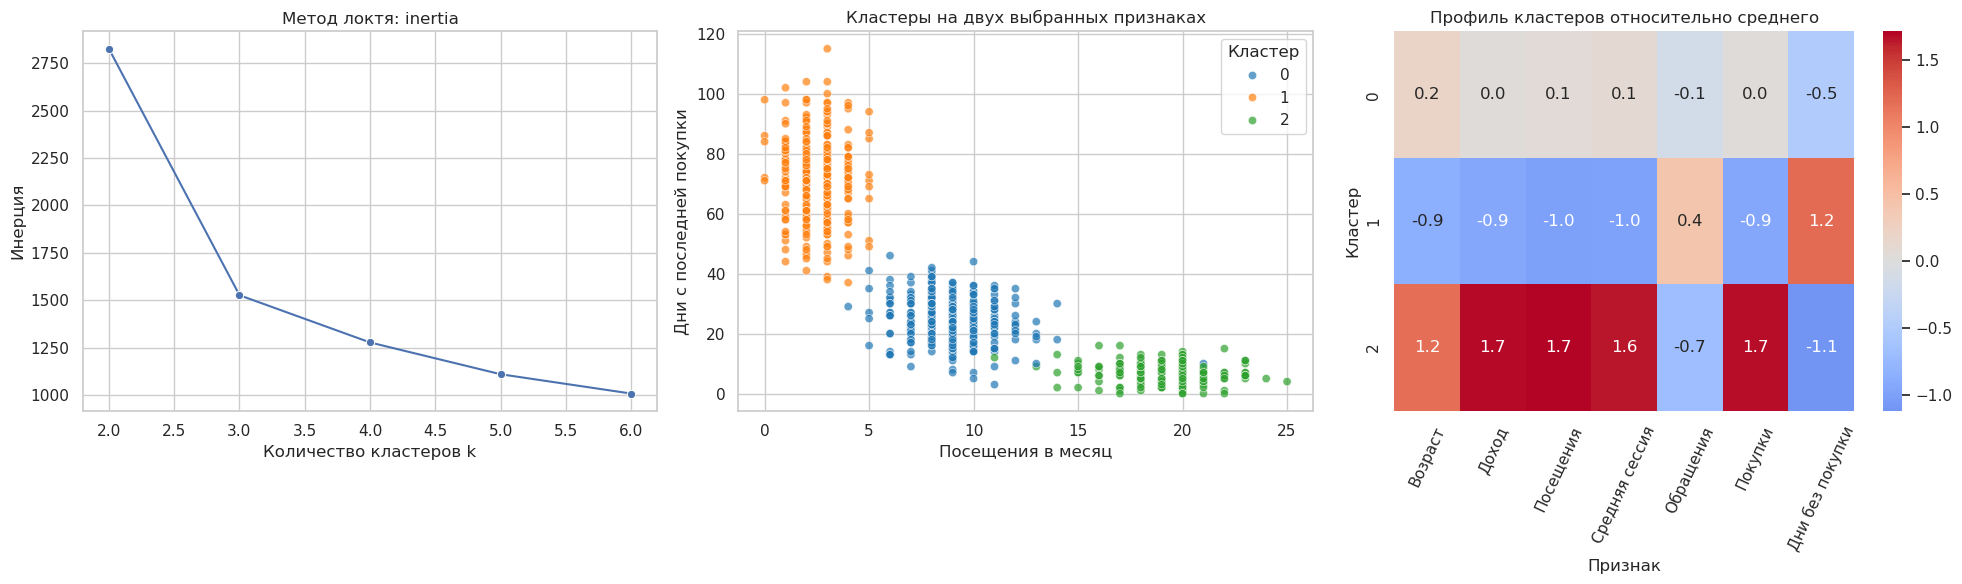

In [14]:
# Рассчитываем стандартизированные средние признаки кластеров для тепловой карты.
cluster_profile_scaled = pd.DataFrame(clustering_scaler.transform(cluster_profile), index=cluster_profile.index, columns=clustering_feature_columns)
# Переименовываем столбцы тепловой карты на русский язык.
cluster_profile_scaled = cluster_profile_scaled.rename(columns=feature_names_ru)
# Создаём фигуру из трёх областей.
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# Строим график inertia для разных k.
sns.lineplot(data=clustering_quality, x='k', y='inertia', marker='o', ax=axes[0])
# Добавляем заголовок графика inertia.
axes[0].set_title('Метод локтя: inertia')
# Подписываем горизонтальную ось первого графика.
axes[0].set_xlabel('Количество кластеров k')
# Подписываем вертикальную ось первого графика.
axes[0].set_ylabel('Инерция')
# Строим scatter plot клиентов по двум признакам.
sns.scatterplot(data=clustered_customers, x='visits_per_month', y='days_since_last_purchase', hue='cluster', palette='tab10', alpha=0.70, ax=axes[1])
# Переводим заголовок легенды на русский язык.
axes[1].legend(title='Кластер')
# Добавляем заголовок scatter plot.
axes[1].set_title('Кластеры на двух выбранных признаках')
# Подписываем горизонтальную ось scatter plot.
axes[1].set_xlabel('Посещения в месяц')
# Подписываем вертикальную ось scatter plot.
axes[1].set_ylabel('Дни с последней покупки')
# Строим тепловую карту профилей кластеров.
sns.heatmap(cluster_profile_scaled, annot=True, fmt='.1f', cmap='coolwarm', center=0, ax=axes[2])
# Добавляем заголовок тепловой карты.
axes[2].set_title('Профиль кластеров относительно среднего')
# Подписываем горизонтальную ось тепловой карты.
axes[2].set_xlabel('Признак')
# Подписываем вертикальную ось тепловой карты.
axes[2].set_ylabel('Кластер')
# Поворачиваем названия признаков для читаемости.
axes[2].tick_params(axis='x', rotation=65)
# Корректируем расположение элементов.
plt.tight_layout()
# Сохраняем графики кластеризации в PNG.
fig.savefig(CLUSTERING_PLOT_PATH, dpi=170, bbox_inches='tight')
# Показываем графики кластеризации.
plt.show()

## 29. Чем отличаются три решения

| Задача | Есть правильный ответ? | Что прогнозируем или ищем | Модель |
|---|---|---|---|
| Регрессия | Да | Число | LinearRegression |
| Классификация | Да | Класс 0 или 1 | LogisticRegression |
| Кластеризация | Нет | Группы похожих объектов | KMeans |

Регрессия и классификация проверяются на отложенном Test.

Кластеризация не имеет обычного правильного ответа. Поэтому используются silhouette score, устойчивость и содержательная интерпретация групп.

## 30. Ограничения учебного примера

- Данные синтетические и специально сделаны достаточно понятными для первых шагов.
- Используется один случайный Train/Test split. В реальном проекте часто применяют кросс-валидацию или временное разделение.
- Модели простые и не настраиваются по большому набору гиперпараметров.
- Классификационный порог 0,5 не оптимизируется по стоимости ошибок.
- Кластеры оцениваются на одной выборке; их стабильность на новых данных не проверяется.
- Признаки не должны использоваться для реальных решений о людях.
- Хорошая метрика на синтетических данных не означает готовность модели к production.

## 31. Финальный QA

Последняя ячейка проверяет ключевые условия:

- правильный размер файлов;
- отсутствие пропусков и повторов;
- отсутствие целевых колонок в clustering-датасете;
- отсутствие пересечения Train и Test;
- превосходство моделей над baseline по выбранным метрикам;
- допустимые диапазоны метрик;
- существование сохранённых графиков.

In [15]:
# Проверяем размер supervised-датасета.
assert supervised_df.shape == (800, 10), 'Неверный размер supervised-датасета.'
# Проверяем размер clustering-датасета.
assert clustering_df.shape == (800, 8), 'Неверный размер clustering-датасета.'
# Проверяем отсутствие пропусков в supervised-датасете.
assert supervised_df.isna().sum().sum() == 0, 'В supervised-датасете есть пропуски.'
# Проверяем отсутствие пропусков в clustering-датасете.
assert clustering_df.isna().sum().sum() == 0, 'В clustering-датасете есть пропуски.'
# Проверяем отсутствие регрессионной цели в clustering-датасете.
assert 'monthly_spend_rub' not in clustering_df.columns, 'В clustering-датасете осталась регрессионная цель.'
# Проверяем отсутствие классификационной цели в clustering-датасете.
assert 'premium_buyer' not in clustering_df.columns, 'В clustering-датасете осталась классификационная цель.'
# Проверяем отсутствие пересечения регрессионных Train и Test.
assert set(X_reg_train.index).isdisjoint(set(X_reg_test.index)), 'Регрессионные Train и Test пересекаются.'
# Проверяем отсутствие пересечения классификационных Train и Test.
assert set(X_cls_train.index).isdisjoint(set(X_cls_test.index)), 'Классификационные Train и Test пересекаются.'
# Проверяем, что MAE линейной регрессии лучше baseline.
assert regression_mae < regression_baseline_mae, 'Регрессия не превзошла baseline по MAE.'
# Проверяем допустимый диапазон R².
assert np.isfinite(regression_r2), 'R² должен быть конечным числом.'
# Проверяем, что F1 классификатора лучше baseline.
assert classification_f1 > classification_baseline_f1, 'Классификация не превзошла baseline по F1.'
# Проверяем допустимые диапазоны метрик классификации.
assert all(0 <= metric <= 1 for metric in [classification_accuracy, classification_precision, classification_recall, classification_f1]), 'Метрики классификации вышли за диапазон 0–1.'
# Проверяем допустимый диапазон silhouette score.
assert -1 <= final_silhouette <= 1, 'Silhouette score вышел за допустимый диапазон.'
# Проверяем, что найдено выбранное количество кластеров.
assert clustered_customers['cluster'].nunique() == best_k, 'Фактическое число кластеров не совпадает с best_k.'
# Проверяем существование графика регрессии.
assert REGRESSION_PLOT_PATH.exists(), 'График регрессии не сохранён.'
# Проверяем существование графика классификации.
assert CLASSIFICATION_PLOT_PATH.exists(), 'График классификации не сохранён.'
# Проверяем существование графика кластеризации.
assert CLUSTERING_PLOT_PATH.exists(), 'График кластеризации не сохранён.'
# Печатаем финальный статус проверки.
print('QA PASSED: данные, разделение, baseline, модели, метрики и графики проверены.')

QA PASSED: данные, разделение, baseline, модели, метрики и графики проверены.


## 32. Итоговые выводы

Линейная регрессия прогнозирует числовые расходы и сравнивается с baseline по MAE, RMSE и R².

Логистическая регрессия прогнозирует класс 0 или 1 и оценивается не только по accuracy, но и по precision, recall, F1 и матрице ошибок.

K-Means работает без готового правильного ответа. Количество групп выбирается по внутренним метрикам, а смысл кластеров определяется по профилям признаков.

Главная последовательность работы с ML:

**задача → данные → признаки и target → Train/Test → baseline → модель → метрики → ошибки → ограничения**.

## Источники по используемым методам

- Train/Test split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- LinearRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- LogisticRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Confusion matrix: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- MAE: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- K-Means: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- Silhouette score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

Интерфейсы библиотек могут изменяться между версиями. Для воспроизведения используется файл `requirements_beginner_ml.txt`.